In [1]:
pip install EMD-signal

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import PyEMD
print(PyEMD.__version__)

1.6.4


In [3]:
import matplotlib.pyplot as plt
# 导入matplotlib的pyplot模块，用于数据可视化。
import tensorflow as tf
# 导入tensorflow库，用于深度学习模型的构建和训练
from PyEMD import EMD, EEMD, CEEMDAN
# 从pyemd库导入EMD, EEMD, CEEMDAN，用于模态分解
import pandas as pd
# 导入pandas库，用于数据处理和分析
import warnings
# 导入warnings库，用于控制警告消息
warnings.filterwarnings("ignore")

In [4]:
gpus = tf.config.experimental.list_physical_devices(device_type='GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

In [5]:
# 用来正常显示中文/英文标签（保持与模板一致）
plt.rcParams['font.sans-serif'] = ['Times New Roman']
# 用来正常显示负号
plt.rcParams['axes.unicode_minus'] = False

In [11]:
df_raw_data = pd.read_csv('Thailand-DroughtPrediction.csv')

# 确保时间列为Datetime并按时间排序
df_raw_data['Month'] = pd.to_datetime(df_raw_data['Month'])
df_raw_data = df_raw_data.sort_values('Month').reset_index(drop=True)

# 只分解目标 cdd（推荐做法），构造与模板一致的 Series 写法
series_close = pd.Series(
    df_raw_data['cdd'].astype(float).values,
    index=df_raw_data['Month']
)
# 创建一个pandas的Series对象。
# df_raw_data['cdd'].values提取'cdd'列的值作为Series的数据。
# index=df_raw_data['Month']设置Series的索引为时间戳（YYYY-MM）
print(series_close)

Month
1950-01-01    24.75
1950-02-01    25.13
1950-03-01    22.73
1950-04-01    10.39
1950-05-01     5.81
              ...  
2023-08-01     2.83
2023-09-01     1.45
2023-10-01     4.86
2023-11-01    13.28
2023-12-01    24.08
Length: 888, dtype: float64


In [12]:
def ceemdan_decompose(series=None, trials=100):
    # 定义CEEMDAN分解函数。
    # series: 待分解的时间序列数据。
    # trials: CEEMDAN的试验次数，用于生成噪声。

    decom = CEEMDAN()
    # 创建CEEMDAN对象。

    decom.trials = trials
    # 设置CEEMDAN对象的试验次数。

    df_ceemdan = pd.DataFrame(decom(series.values).T)
    # 对时间序列数据执行CEEMDAN分解，并将结果转置后转换为DataFrame。

    df_ceemdan.columns = ['imf' + str(i+1) for i in range(len(df_ceemdan.columns))]
    # 为DataFrame的每一列命名，表示每个内在模态函数（IMF）。

    return df_ceemdan
    # 返回分解结果的DataFrame。

In [13]:
df_ceemdan = ceemdan_decompose(series_close)
# 对series_close进行CEEMDAN分解，并返回结果的DataFrame。

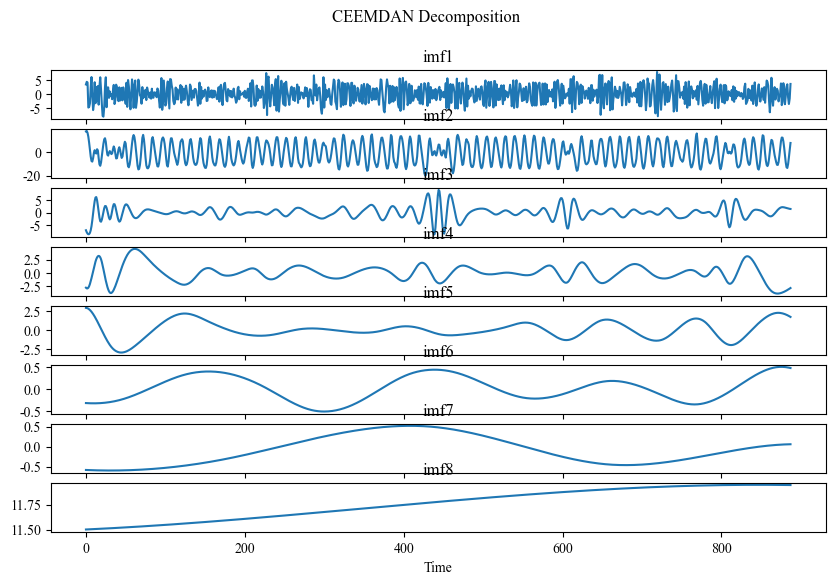

In [14]:
# 可视化VMD分解结果
fig, axs = plt.subplots(nrows=len(df_ceemdan.columns), figsize=(10, 6), sharex=True)
# 创建一个绘图对象和多个子图对象。
for i, col in enumerate(df_ceemdan.columns):
    axs[i].plot(df_ceemdan[col])
    axs[i].set_title(col)
    # 遍历每个模态并绘制在子图上。

plt.suptitle('CEEMDAN Decomposition')
# 设置图表的总标题。

plt.xlabel('Time')
# 设置x轴的标签。

plt.show()
# 显示图表。

In [15]:
print(df_ceemdan)
df_ceemdan.to_excel("CEEMDAN-THAILAND-CDD.xlsx",index=False)
#保存数据为CEEMDAN-CHINA-CDD.xlsx

         imf1       imf2      imf3      imf4      imf5      imf6      imf7  \
0    3.379495  17.580829 -6.970635 -2.792810  2.955511 -0.317788 -0.585260   
1    4.293228  17.960945 -7.734918 -2.923951  2.938722 -0.318941 -0.586116   
2    4.092542  16.351497 -8.279152 -2.931496  2.902119 -0.319972 -0.586944   
3   -4.746721  13.045300 -8.549639 -2.797593  2.845495 -0.320882 -0.587744   
4   -4.568431   8.014878 -8.485310 -2.512922  2.769807 -0.321668 -0.588517   
..        ...        ...       ...       ...       ...       ...       ...   
883  3.437786 -13.472795  1.620891 -3.239963  1.991215  0.490164  0.054875   
884 -1.224284 -10.147438  1.542204 -3.149471  1.938737  0.487027  0.055509   
885 -3.492146  -4.444251  1.481439 -3.055161  1.882895  0.483534  0.056085   
886 -1.582138   2.077353  1.434428 -2.957274  1.823846  0.479691  0.056603   
887  3.555936   7.741424  1.396980 -2.856027  1.761746  0.475504  0.057065   

          imf8  
0    11.500657  
1    11.501031  
2    11.5014